#  **Phân tích đơn biến trên `features.csv`** 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
features = pd.read_csv('data/features.csv')


In [19]:
print(features.head())

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  


In [20]:
print(features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None


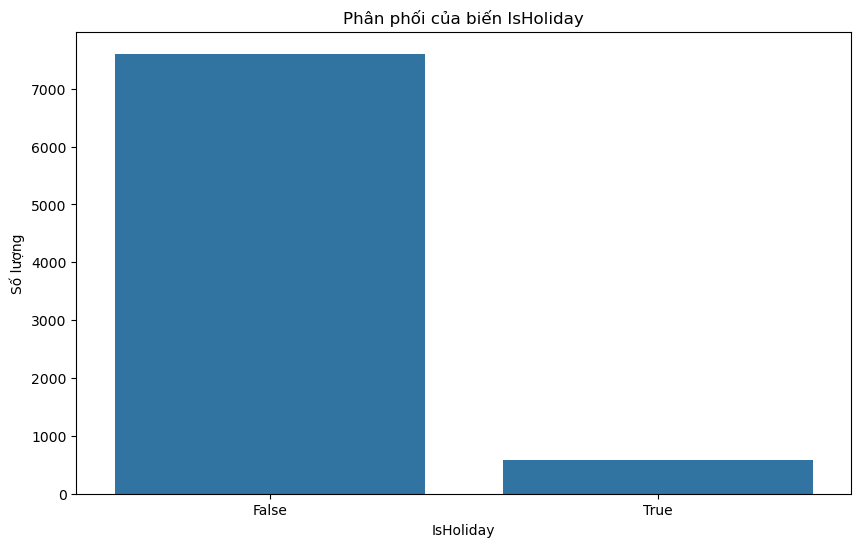

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='IsHoliday', data=features)  # Biểu đồ phân phối của biến ngày lễ
plt.title('Phân phối của biến IsHoliday')
plt.xlabel('IsHoliday')
plt.ylabel('Số lượng')
plt.show()

**Phân tích biểu đồ phân phối của biến `IsHoliday`:**

- **Mục đích**: Biểu đồ này kiểm tra sự phân phối của biến **`IsHoliday`**, một biến phân loại với giá trị **True** (ngày lễ) và **False** (không phải ngày lễ).
- **Kết quả**: Phần lớn các tuần trong bộ dữ liệu không phải là ngày lễ (**False**), chiếm tỷ lệ rất lớn so với các tuần có ngày lễ (**True**), mà số lượng là rất ít.
- **Ý nghĩa**: Điều này cho thấy các ngày lễ trong bộ dữ liệu này là ít, điều này có thể ảnh hưởng đến phân tích sau này vì các yếu tố như khuyến mãi hoặc hành vi mua sắm có thể thay đổi trong những tuần có ngày lễ.

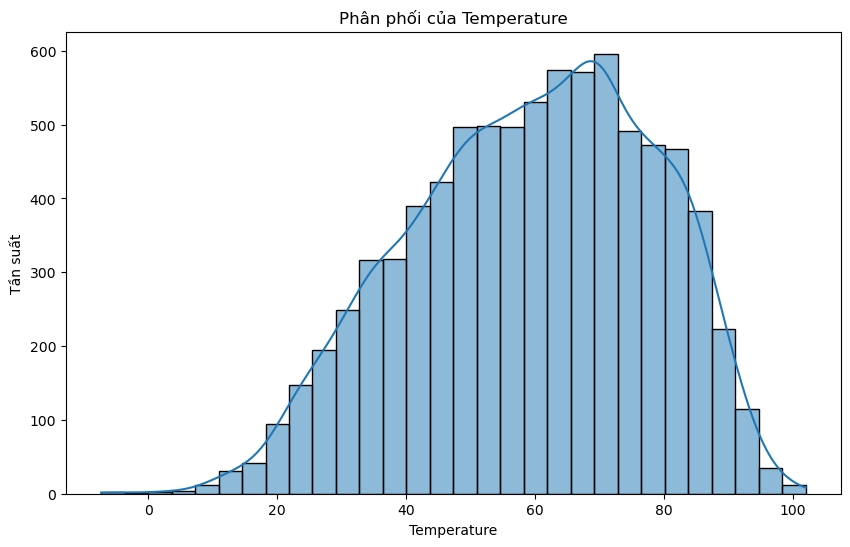

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(features['Temperature'], kde=True, bins=30)  
plt.title('Phân phối của Temperature')
plt.xlabel('Temperature')
plt.ylabel('Tần suất')
plt.show()

**Phân tích biểu đồ phân phối của `Temperature`:**

- **Mục đích**: Biểu đồ này thể hiện sự phân phối của biến **`Temperature`** (Nhiệt độ).
- **Kết quả**: Phân phối của **`Temperature`** có hình dạng **đối xứng và hình chuông**, với một đỉnh rõ ràng quanh **60°F**. Sự phân phối này cho thấy nhiệt độ trong dữ liệu của bạn tập trung chủ yếu trong khoảng từ **50°F đến 70°F**, có sự giảm dần ở hai đầu.
- **Ý nghĩa**: Đây là phân phối chuẩn, cho thấy **nhiệt độ** trong bộ dữ liệu có sự phân bố đồng đều, không có giá trị cực kỳ cao hoặc thấp. Điều này có thể ảnh hưởng đến các phân tích và dự báo liên quan đến nhiệt độ trong tương lai.



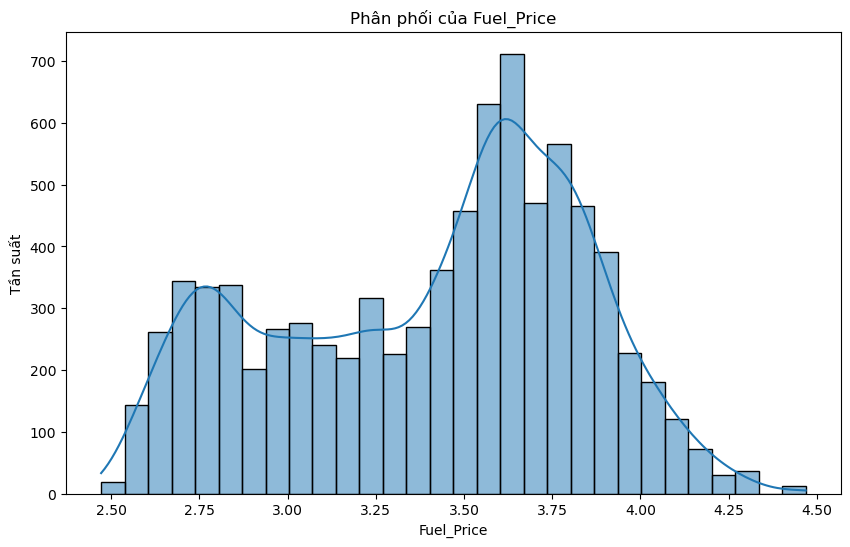

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(features['Fuel_Price'], kde=True, bins=30)  # Biểu đồ phân phối của biến Giá xăng
plt.title('Phân phối của Fuel_Price')
plt.xlabel('Fuel_Price')
plt.ylabel('Tần suất')
plt.show()

**Phân tích biểu đồ phân phối của `Fuel_Price`:**

- **Mục đích**: Biểu đồ này thể hiện sự phân phối của biến **`Fuel_Price`** (Giá xăng).
- **Kết quả**: Phân phối của **`Fuel_Price`** có hình dạng **đối xứng** và hơi lệch phải, với đỉnh rõ ràng quanh **$3.50**. Giá xăng chủ yếu tập trung trong khoảng từ **$2.50 đến $4.00**, với tần suất giảm dần khi giá xăng tăng lên trên mức này.
- **Ý nghĩa**: Điều này cho thấy trong bộ dữ liệu, **giá xăng** có một phạm vi khá ổn định và không có sự biến động quá lớn, mặc dù giá xăng có sự phân bố trải đều từ thấp đến cao. Biểu đồ cũng cho thấy các giá trị ngoại lai có thể xuất hiện khi giá xăng vượt quá mức này.


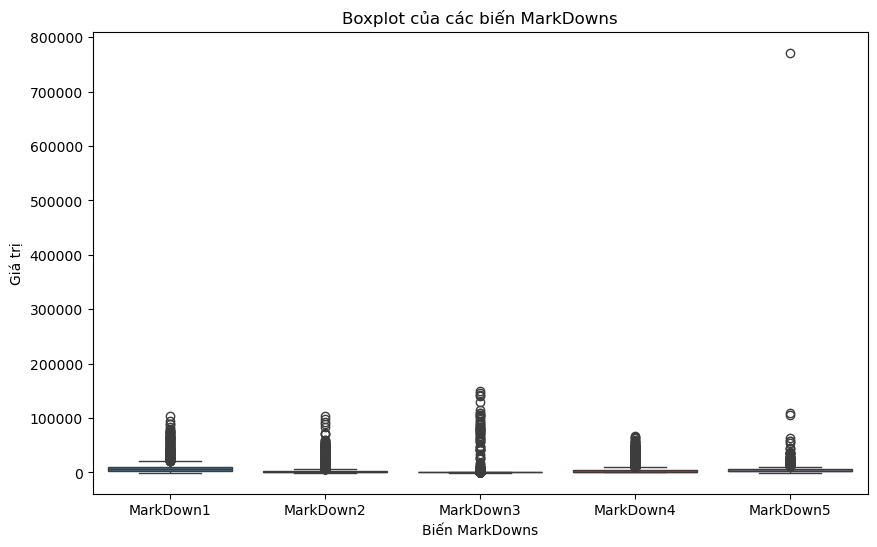

In [24]:
features_cleaned = features[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=features_cleaned)
plt.title('Boxplot của các biến MarkDowns')
plt.xlabel('Biến MarkDowns')
plt.ylabel('Giá trị')
plt.show()


- **Mục đích**: Biểu đồ boxplot này kiểm tra sự phân bố và các **giá trị ngoại lai** trong các mức giảm giá **`MarkDown1` đến `MarkDown5`**.
- **Kết quả**:
  - Hầu hết các mức giảm giá có giá trị tập trung quanh **0**, cho thấy trong nhiều tuần không có giảm giá áp dụng.
  - Các giá trị ngoại lai (hình tròn nằm ngoài whiskers) có thể chỉ ra rằng có một số tuần có mức giảm giá rất cao, vượt xa mức bình thường.
  - **Giảm giá `MarkDown1` và `MarkDown3`** có sự xuất hiện của các giá trị ngoại lai rất lớn, với giá trị có thể lên tới hơn **100,000** hoặc thậm chí **700,000**.

- **Ý nghĩa**: Biểu đồ này cho thấy mức độ phân tán và sự tồn tại của các giá trị **ngoại lai** trong các mức giảm giá. Những giá trị ngoại lai này có thể phản ánh các chương trình khuyến mãi đặc biệt hoặc lỗi dữ liệu.

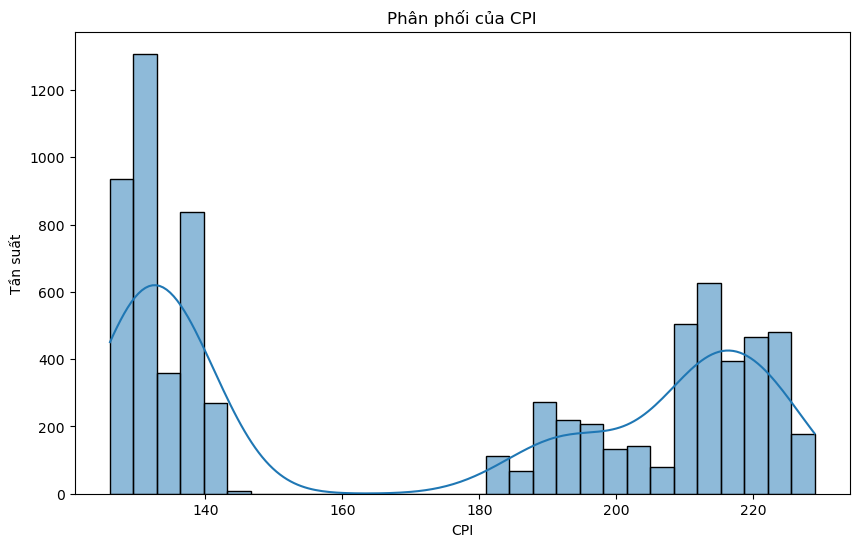

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(features['CPI'], kde=True, bins=30)  # Vẽ biểu đồ phân phối của CPI
plt.title('Phân phối của CPI')  # Tiêu đề biểu đồ
plt.xlabel('CPI')  # Nhãn trục hoành
plt.ylabel('Tần suất')  # Nhãn trục tung
plt.show()

- **Mục đích**: Biểu đồ này thể hiện sự phân phối của biến **`CPI`** (Chỉ số giá tiêu dùng).
- **Kết quả**: 
  - Biểu đồ cho thấy sự phân phối **lệch phải** (skewed right), với hai nhóm đỉnh rõ ràng:
    - Một nhóm đỉnh ở giá trị thấp hơn **150**, với tần suất cao nhất, cho thấy phần lớn các giá trị **CPI** tập trung vào khoảng này.
    - Một nhóm đỉnh khác xuất hiện ở khoảng **200 đến 220**, cho thấy sự gia tăng **CPI** ở các giá trị cao hơn.
  - **Dạng phân phối** cho thấy dữ liệu có thể bị ảnh hưởng bởi các yếu tố khác nhau, chẳng hạn như sự thay đổi giá cả, lạm phát trong các giai đoạn khác nhau.
  
- **Ý nghĩa**: Biểu đồ này giúp ta hiểu được sự phân phối của **CPI** trong bộ dữ liệu. Các đỉnh này có thể chỉ ra những giai đoạn thay đổi mạnh mẽ trong nền kinh tế (lạm phát hoặc suy thoái), cần xem xét khi làm các phân tích kinh tế hoặc dự báo.

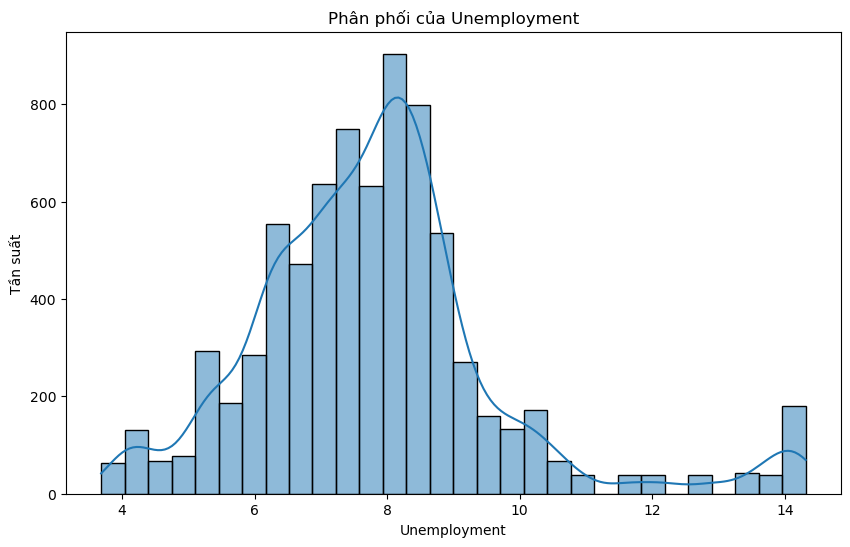

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(features['Unemployment'], kde=True, bins=30)  # Vẽ biểu đồ phân phối của tỷ lệ thất nghiệp
plt.title('Phân phối của Unemployment')  # Tiêu đề biểu đồ
plt.xlabel('Unemployment')  # Nhãn trục hoành
plt.ylabel('Tần suất')  # Nhãn trục tung
plt.show()

**Phân tích biểu đồ phân phối của `Unemployment`:**

- **Mục đích**: Biểu đồ này thể hiện sự phân phối của biến **`Unemployment`** (Tỷ lệ thất nghiệp).
- **Kết quả**: 
  - Phân phối của **`Unemployment`** có hình dạng **đối xứng và hình chuông** (phân phối chuẩn).
  - Đỉnh của phân phối rơi vào khoảng tỷ lệ thất nghiệp **7% đến 9%**, cho thấy phần lớn các giá trị **Unemployment** tập trung ở khu vực này.
  - Các giá trị lớn hơn **10%** và nhỏ hơn **5%** ít xuất hiện hơn, với tần suất giảm dần khi tỷ lệ thất nghiệp tăng hoặc giảm.

- **Ý nghĩa**: Biểu đồ này giúp bạn hiểu được sự phân bố tỷ lệ thất nghiệp trong dữ liệu. Tỷ lệ thất nghiệp phổ biến nhất trong bộ dữ liệu là khoảng **7% đến 9%**. Dữ liệu không có nhiều giá trị cực đoan, cho thấy một sự ổn định trong tỷ lệ thất nghiệp.

### **Kết luận về phân tích đơn biến trên `features.csv`**:

- **Ngày lễ (`IsHoliday`)**:
  - Biến **`IsHoliday`** có sự phân phối không đồng đều, với phần lớn các tuần không phải là ngày lễ (**False**). Điều này cho thấy các tuần có ngày lễ là hiếm, điều này có thể ảnh hưởng đến các yếu tố khác như doanh thu và khuyến mãi, vì chúng thường có tác động lớn trong các kỳ lễ.

- **Nhiệt độ (`Temperature`)**:
  - Biến **`Temperature`** có phân phối đối xứng hình chuông, tập trung chủ yếu quanh mức **60°F**. Điều này cho thấy nhiệt độ trong bộ dữ liệu có sự ổn định và không có các giá trị cực kỳ cao hoặc thấp, với sự phân bố đều đặn trong phạm vi nhiệt độ này.

- **Giá xăng (`Fuel_Price`)**:
  - Biến **`Fuel_Price`** có phân phối lệch phải với giá trị phổ biến nằm trong khoảng từ **$2.50 đến $4.00**. Có một số tuần với giá xăng cực kỳ cao, nhưng nhìn chung, giá xăng có sự biến động ổn định trong phạm vi này.

- **Chỉ số giá tiêu dùng (`CPI`)**:
  - **`CPI`** (Chỉ số giá tiêu dùng) có sự phân phối lệch phải với hai đỉnh rõ ràng: một đỉnh ở giá trị **dưới 150** và một đỉnh ở giá trị **trên 200**. Điều này cho thấy sự thay đổi mạnh mẽ trong giá cả hàng hóa trong nền kinh tế, phản ánh tác động của lạm phát và sự thay đổi chi phí trong thời gian.

- **Tỷ lệ thất nghiệp (`Unemployment`)**:
  - **`Unemployment`** có phân phối đối xứng và hình chuông, với đỉnh tập trung ở khoảng **7% đến 9%**. Điều này cho thấy tỷ lệ thất nghiệp trong dữ liệu có sự ổn định và không có biến động lớn, với tỷ lệ thất nghiệp thấp hơn hoặc cao hơn đều ít xảy ra.

- **Mức giảm giá (`MarkDown1 - MarkDown5`)**:
  - Các biến **`MarkDown1` đến `MarkDown5`** có sự phân bố chặt chẽ ở mức thấp, với phần lớn giá trị nằm ở **0**. Tuy nhiên, có một số giá trị ngoại lai lớn, đặc biệt ở **`MarkDown1` và `MarkDown3`**, cho thấy một số tuần có mức giảm giá cực kỳ cao, có thể do các chương trình khuyến mãi đặc biệt hoặc lỗi dữ liệu.

### **Tóm lại**:
Phân tích đơn biến trên **`features.csv`** giúp ta hiểu rõ hơn về các yếu tố trong dữ liệu, như sự phân phối của **nhiệt độ**, **giá xăng**, **tỷ lệ thất nghiệp**, và **chỉ số giá tiêu dùng**. Những hiểu biết này là bước quan trọng trong việc làm sạch và tiền xử lý dữ liệu, cũng như chuẩn bị cho các mô hình phân tích và dự báo sau này.